# Execution environment, reproducibility controls, and output organization

This notebook initializes a consistent execution environment for both Google Colab and local Python sessions. A structured directory layout is created for figures, tables, serialized data, logs, and run metadata. The cell also records the software environment, fixes the random seed, defines the main computational constants, and writes a run manifest to disk so that all downstream outputs can be traced to a specific run configuration.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
SEED = 20260430

if IN_COLAB:
    try:
        drive.mount("/content/drive", force_remount=False)
        ROOT_DIR = Path("/content/drive/MyDrive/qtrustchain_workspace")
    except Exception:
        ROOT_DIR = Path("/content/qtrustchain_workspace")
else:
    ROOT_DIR = Path.cwd() / "qtrustchain_workspace"

OUTPUT_DIR = ROOT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_DIR = OUTPUT_DIR / "data"
LOG_DIR = OUTPUT_DIR / "logs"
META_DIR = OUTPUT_DIR / "meta"

for d in [ROOT_DIR, OUTPUT_DIR, FIG_DIR, TABLE_DIR, DATA_DIR, LOG_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(SEED)

T = 120
N_REP = 400
N_BOOT = 500
N_SC = 300
M_PSI = 0.02
M_REF = 1.0

ETA_GRID = np.linspace(0.005, 0.32, 90)
A_GRID = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40])
C_GRID = np.array([0.01, 0.02, 0.03, 0.05])

WEIGHTS = {
    "alpha": 1.20,
    "beta": 0.80,
    "gamma": 1.00,
    "delta": 0.45,
    "lam": 1.05,
}

MODEL_CONFIG = {
    "temporal_memory_rho": 0.82,
    "cumulative_stress_mu": 0.18,
    "lagged_consensus": True,
    "seasonal_component": True,
}

run_manifest = {
    "run_id": RUN_ID,
    "seed": SEED,
    "execution_mode": "colab" if IN_COLAB else "local",
    "root_dir": str(ROOT_DIR),
    "output_dir": str(OUTPUT_DIR),
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "matplotlib_version": plt.matplotlib.__version__,
    "T": T,
    "N_REP": N_REP,
    "N_BOOT": N_BOOT,
    "N_SC": N_SC,
    "M_PSI": M_PSI,
    "M_REF": M_REF,
    "eta_grid_size": int(len(ETA_GRID)),
    "a_grid_size": int(len(A_GRID)),
    "c_grid_size": int(len(C_GRID)),
    "weights": WEIGHTS,
    "model_config": MODEL_CONFIG,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
}

manifest_path = META_DIR / f"run_manifest_{RUN_ID}.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2)

run_manifest

{'run_id': '20260502_183254',
 'seed': 20260430,
 'execution_mode': 'local',
 'root_dir': 'F:\\MBZUAI UAE\\16-IEEE-QTRUSTChain\\GitHub\\Q-TRUSTChain\\qtrustchain_workspace',
 'output_dir': 'F:\\MBZUAI UAE\\16-IEEE-QTRUSTChain\\GitHub\\Q-TRUSTChain\\qtrustchain_workspace\\outputs',
 'python_version': '3.10.20',
 'platform': 'Windows-10-10.0.26200-SP0',
 'numpy_version': '2.2.5',
 'pandas_version': '2.3.3',
 'matplotlib_version': '3.10.8',
 'T': 120,
 'N_REP': 400,
 'N_BOOT': 500,
 'N_SC': 300,
 'M_PSI': 0.02,
 'M_REF': 1.0,
 'eta_grid_size': 90,
 'a_grid_size': 8,
 'c_grid_size': 4,
 'weights': {'alpha': 1.2,
  'beta': 0.8,
  'gamma': 1.0,
  'delta': 0.45,
  'lam': 1.05},
 'model_config': {'temporal_memory_rho': 0.82,
  'cumulative_stress_mu': 0.18,
  'lagged_consensus': True,
  'seasonal_component': True},
 'timestamp_utc': '2026-05-02T18:32:54.552371+00:00'}

# Utility functions, deterministic random streams, and core statistical helpers

This cell defines the helper functions used throughout the workflow. These include bounded transformations, deterministic condition-specific random stream generation, terminal-state classification, event-time extraction, threshold-crossing interpolation, interval estimation for binomial proportions, and compact summary statistics for simulated terminal values. Centralizing these definitions keeps later cells concise and ensures that the same computational rules are applied consistently across all analyses.

In [2]:
from math import sqrt

def clip(x, low=0.0, high=1.0):
    return np.clip(x, low, high)


def make_seed_sequence(*tokens):
    entropy = [SEED]
    for token in tokens:
        if isinstance(token, str):
            entropy.extend(token.encode("utf-8"))
        elif isinstance(token, bool):
            entropy.append(int(token))
        else:
            entropy.append(int(round(float(token) * 1_000_000)))
    return np.random.SeedSequence(entropy)


def make_rng(*tokens):
    return np.random.default_rng(make_seed_sequence(*tokens))


def condition_key(eta, a, c):
    return f"eta={eta:.6f}|a={a:.3f}|c={c:.3f}"


def classify_terminal(psi, margin=M_PSI):
    psi = np.asarray(psi, dtype=float)
    stable = psi > margin
    unstable = psi < -margin
    transition = ~(stable | unstable)
    return stable, transition, unstable


def first_event_time(mask):
    mask = np.asarray(mask)
    return np.nan if not mask.any() else int(np.argmax(mask))


def crossing_x(x, y, target=0.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = y - target

    for i in range(len(x) - 1):
        if np.isnan(z[i]) or np.isnan(z[i + 1]):
            continue
        if z[i] == 0:
            return float(x[i])
        if z[i] * z[i + 1] < 0:
            dx = x[i + 1] - x[i]
            dz = z[i + 1] - z[i]
            return float(x[i] - z[i] * dx / dz)

    return np.nan


def wilson_interval(k, n, z=1.959963984540054):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2.0 * n)) / denom
    radius = z * sqrt((p * (1.0 - p) + z**2 / (4.0 * n)) / n) / denom
    return max(0.0, center - radius), min(1.0, center + radius)


def summarize_terminal_distribution(values):
    values = np.asarray(values, dtype=float)
    return {
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)),
        "sem": float(np.std(values, ddof=1) / np.sqrt(len(values))),
        "q05": float(np.quantile(values, 0.05)),
        "q50": float(np.quantile(values, 0.50)),
        "q95": float(np.quantile(values, 0.95)),
    }


helper_check = {
    "eta_grid_points": int(len(ETA_GRID)),
    "a_grid_points": int(len(A_GRID)),
    "c_grid_points": int(len(C_GRID)),
    "example_key": condition_key(ETA_GRID[0], A_GRID[0], C_GRID[0]),
    "wilson_example": wilson_interval(200, 400),
}

helper_check

{'eta_grid_points': 90,
 'a_grid_points': 8,
 'c_grid_points': 4,
 'example_key': 'eta=0.005000|a=0.050|c=0.010',
 'wilson_example': (0.451234504169709, 0.548765495830291)}

# Dynamical process specification and simulation functions

This cell defines the state evolution model used throughout the workflow. The first function simulates a full trajectory for a single realization and returns the state path, component processes, cumulative stress, and intervention activity. The second function provides an efficient batched terminal-state simulation for grid-based analysis. Both functions follow the same structural assumptions so that trajectory-level diagnostics and grid-level endpoint summaries remain directly comparable.

In [3]:
def simulate_trajectory(eta, a, c, rng, mode="full", adaptive=False):
    alpha = WEIGHTS["alpha"]
    beta = WEIGHTS["beta"]
    gamma = WEIGHTS["gamma"]
    delta = WEIGHTS["delta"]
    lam = WEIGHTS["lam"]

    rho = MODEL_CONFIG["temporal_memory_rho"]
    mu = MODEL_CONFIG["cumulative_stress_mu"]

    if mode == "memoryless":
        rho = 0.0
    if mode == "no_cumulative_stress":
        mu = 0.0

    F = np.zeros(T, dtype=float)
    psi = np.zeros(T, dtype=float)
    rq = np.zeros(T, dtype=float)
    rc = np.zeros(T, dtype=float)
    rb = np.zeros(T, dtype=float)
    co = np.zeros(T, dtype=float)
    reserve = np.zeros(T, dtype=float)
    stress_path = np.zeros(T, dtype=float)
    interventions = np.zeros(T, dtype=int)

    F_prev = -0.18
    stress = 0.0

    for t in range(T):
        tau = t / (T - 1)
        lag = 1.0 - np.exp(-3.2 * tau)
        seasonal = 0.012 * np.sin(2.0 * np.pi * t / T)

        v_rq = clip(eta + 0.030 * a + 0.018 * c + 0.030 * tau + seasonal + rng.normal(0.0, 0.006))
        v_rc = clip(0.42 * a + 0.25 * eta + 0.020 * tau + rng.normal(0.0, 0.004))
        v_rb = clip((0.16 + 1.85 * a + 2.10 * c) * lag + rng.normal(0.0, 0.006))
        v_co = clip(0.35 * c + 0.22 * a + 0.12 * eta + 0.025 * tau + rng.normal(0.0, 0.003))
        v_reserve = clip(0.72 - 0.35 * a - 0.25 * c - 0.20 * eta - 0.10 * tau + rng.normal(0.0, 0.004))

        if mode == "no_quantum_risk":
            v_rq = 0.0
        if mode == "no_crypto_risk":
            v_rc = 0.0
        if mode == "no_consensus_risk":
            v_rb = 0.0
        if mode == "no_operational_cost":
            v_co = 0.0
        if mode == "no_resilience_reserve":
            v_reserve = 0.0
        if mode == "qkd_only":
            v_rc, v_rb, v_co = 0.0, 0.0, 0.0
        if mode == "pqc_consensus_only":
            v_rq, v_co, v_reserve = 0.0, 0.0, 0.35
        if mode == "static_threshold":
            v_rb, v_rc, v_co, v_reserve = 0.0, 0.0, 0.0, 0.0

        stress = 0.96 * stress + v_rq + 0.55 * v_rb + 0.25 * v_rc
        stress_term = mu * stress / T

        F_raw = alpha * v_rq + beta * v_rc + gamma * v_rb + delta * v_co + stress_term - lam * v_reserve - 0.52

        if adaptive and t >= 6:
            slope = F_prev - F[t - 2] if t >= 2 else 0.0
            if (F_prev > -0.06) or (slope > 0.010):
                interventions[t] = 1
                F_raw -= 0.145
                stress *= 0.88

        F_t = F_raw if mode == "memoryless" else rho * F_prev + (1.0 - rho) * F_raw

        F[t] = F_t
        psi[t] = -F_t / M_REF
        rq[t] = v_rq
        rc[t] = v_rc
        rb[t] = v_rb
        co[t] = v_co
        reserve[t] = v_reserve
        stress_path[t] = stress

        F_prev = F_t

    return {
        "F": F,
        "psi": psi,
        "rq": rq,
        "rc": rc,
        "rb": rb,
        "co": co,
        "reserve": reserve,
        "stress": stress_path,
        "interventions": interventions,
    }


def simulate_terminal_batch(eta, a, c, rng, n_rep=N_REP, mode="full"):
    alpha = WEIGHTS["alpha"]
    beta = WEIGHTS["beta"]
    gamma = WEIGHTS["gamma"]
    delta = WEIGHTS["delta"]
    lam = WEIGHTS["lam"]

    rho = MODEL_CONFIG["temporal_memory_rho"]
    mu = MODEL_CONFIG["cumulative_stress_mu"]

    if mode == "memoryless":
        rho = 0.0
    if mode == "no_cumulative_stress":
        mu = 0.0

    F_prev = np.full(n_rep, -0.18, dtype=float)
    stress = np.zeros(n_rep, dtype=float)

    for t in range(T):
        tau = t / (T - 1)
        lag = 1.0 - np.exp(-3.2 * tau)
        seasonal = 0.012 * np.sin(2.0 * np.pi * t / T)

        v_rq = clip(eta + 0.030 * a + 0.018 * c + 0.030 * tau + seasonal + rng.normal(0.0, 0.006, n_rep))
        v_rc = clip(0.42 * a + 0.25 * eta + 0.020 * tau + rng.normal(0.0, 0.004, n_rep))
        v_rb = clip((0.16 + 1.85 * a + 2.10 * c) * lag + rng.normal(0.0, 0.006, n_rep))
        v_co = clip(0.35 * c + 0.22 * a + 0.12 * eta + 0.025 * tau + rng.normal(0.0, 0.003, n_rep))
        v_reserve = clip(0.72 - 0.35 * a - 0.25 * c - 0.20 * eta - 0.10 * tau + rng.normal(0.0, 0.004, n_rep))

        if mode == "no_quantum_risk":
            v_rq = np.zeros(n_rep)
        if mode == "no_crypto_risk":
            v_rc = np.zeros(n_rep)
        if mode == "no_consensus_risk":
            v_rb = np.zeros(n_rep)
        if mode == "no_operational_cost":
            v_co = np.zeros(n_rep)
        if mode == "no_resilience_reserve":
            v_reserve = np.zeros(n_rep)
        if mode == "qkd_only":
            v_rc, v_rb, v_co = np.zeros(n_rep), np.zeros(n_rep), np.zeros(n_rep)
        if mode == "pqc_consensus_only":
            v_rq, v_co, v_reserve = np.zeros(n_rep), np.zeros(n_rep), np.full(n_rep, 0.35)
        if mode == "static_threshold":
            v_rb, v_rc, v_co, v_reserve = np.zeros(n_rep), np.zeros(n_rep), np.zeros(n_rep), np.zeros(n_rep)

        stress = 0.96 * stress + v_rq + 0.55 * v_rb + 0.25 * v_rc
        stress_term = mu * stress / T
        F_raw = alpha * v_rq + beta * v_rc + gamma * v_rb + delta * v_co + stress_term - lam * v_reserve - 0.52
        F_prev = F_raw if mode == "memoryless" else rho * F_prev + (1.0 - rho) * F_raw

    return -F_prev / M_REF


trajectory_check = simulate_trajectory(0.10, 0.20, 0.02, make_rng("trajectory_check"))
batch_check = simulate_terminal_batch(0.10, 0.20, 0.02, make_rng("batch_check"), n_rep=32)

simulation_check = {
    "trajectory_keys": list(trajectory_check.keys()),
    "trajectory_length": int(len(trajectory_check["psi"])),
    "batch_shape": tuple(batch_check.shape),
    "batch_mean_terminal_psi": float(np.mean(batch_check)),
}

simulation_check

{'trajectory_keys': ['F',
  'psi',
  'rq',
  'rc',
  'rb',
  'co',
  'reserve',
  'stress',
  'interventions'],
 'trajectory_length': 120,
 'batch_shape': (32,),
 'batch_mean_terminal_psi': 0.21426801283744876}

# Consistency check between trajectory-level and batched terminal simulation

This cell verifies that the single-realization simulator and the batched terminal simulator produce closely aligned terminal-state distributions under the same operating conditions. The comparison is carried out on a small set of representative parameter combinations using independent condition-specific random streams. The objective is to confirm that endpoint estimation and trajectory-level analysis remain numerically consistent.

In [4]:
validation_configs = [
    (0.080, 0.10, 0.01),
    (0.140, 0.20, 0.02),
    (0.220, 0.30, 0.05),
]

validation_rows = []

for eta, a, c in validation_configs:
    scalar_terminal = []
    child_streams = make_seed_sequence("scalar_validation", eta, a, c).spawn(600)

    for child in child_streams:
        local_rng = np.random.default_rng(child)
        out = simulate_trajectory(eta, a, c, local_rng, mode="full", adaptive=False)
        scalar_terminal.append(out["psi"][-1])

    scalar_terminal = np.asarray(scalar_terminal, dtype=float)

    batch_rng = make_rng("batch_validation", eta, a, c)
    batch_terminal = simulate_terminal_batch(eta, a, c, batch_rng, n_rep=600, mode="full")

    validation_rows.append({
        "eta": float(eta),
        "a": float(a),
        "c": float(c),
        "scalar_mean": float(np.mean(scalar_terminal)),
        "batch_mean": float(np.mean(batch_terminal)),
        "abs_mean_diff": float(abs(np.mean(scalar_terminal) - np.mean(batch_terminal))),
        "scalar_std": float(np.std(scalar_terminal, ddof=1)),
        "batch_std": float(np.std(batch_terminal, ddof=1)),
        "abs_std_diff": float(abs(np.std(scalar_terminal, ddof=1) - np.std(batch_terminal, ddof=1))),
        "scalar_q50": float(np.quantile(scalar_terminal, 0.50)),
        "batch_q50": float(np.quantile(batch_terminal, 0.50)),
        "abs_q50_diff": float(abs(np.quantile(scalar_terminal, 0.50) - np.quantile(batch_terminal, 0.50))),
    })

validation_df = pd.DataFrame(validation_rows)
validation_path = TABLE_DIR / "simulation_validation.csv"
validation_df.to_csv(validation_path, index=False)

validation_df

,eta,a,c,scalar_mean,batch_mean,abs_mean_diff,scalar_std,batch_std,abs_std_diff,scalar_q50,batch_q50,abs_q50_diff
0,0.08,0.1,0.01,0.536781,0.536591,0.000190,0.003460,0.003610,0.000150,0.536760,0.536591,0.000170
1,0.14,0.2,0.02,0.145581,0.145241,0.000339,0.003428,0.003459,0.000031,0.145465,0.145187,0.000279
2,0.22,0.3,0.05,-0.329676,-0.329396,0.000280,0.003310,0.003291,0.000019,-0.329583,-0.329491,0.000092


# Grid-based endpoint simulation and replicate-level storage

This cell evaluates the full operating grid and stores both compact summaries and replicate-level terminal values for each condition. The summary table includes distributional descriptors, class counts, class probabilities, and interval estimates for the stable-state probability. The replicate-level terminal outputs are retained because later threshold estimation, sensitivity analysis, and comparative diagnostics are computed directly from the simulated outcomes rather than from transformed summaries.

In [5]:
import time

endpoint_rows = []
terminal_store = {}

total_conditions = len(ETA_GRID) * len(A_GRID) * len(C_GRID)
completed = 0
t0 = time.time()

for a in A_GRID:
    for c in C_GRID:
        for eta in ETA_GRID:
            local_rng = make_rng("endpoint", eta, a, c)
            terminal_psi = simulate_terminal_batch(
                eta=eta,
                a=a,
                c=c,
                rng=local_rng,
                n_rep=N_REP,
                mode="full",
            ).astype(np.float32)

            stable, transition, unstable = classify_terminal(terminal_psi, margin=M_PSI)

            stable_count = int(np.sum(stable))
            transition_count = int(np.sum(transition))
            unstable_count = int(np.sum(unstable))
            stable_low, stable_high = wilson_interval(stable_count, N_REP)

            dist = summarize_terminal_distribution(terminal_psi)

            endpoint_rows.append({
                "eta": float(eta),
                "a": float(a),
                "c": float(c),
                "mean_terminal_psi": dist["mean"],
                "std_terminal_psi": dist["std"],
                "sem_terminal_psi": dist["sem"],
                "q05_terminal_psi": dist["q05"],
                "q50_terminal_psi": dist["q50"],
                "q95_terminal_psi": dist["q95"],
                "stable_count": stable_count,
                "transition_count": transition_count,
                "unstable_count": unstable_count,
                "p_stable": stable_count / N_REP,
                "p_transition": transition_count / N_REP,
                "p_unstable": unstable_count / N_REP,
                "p_stable_low": stable_low,
                "p_stable_high": stable_high,
            })

            terminal_store[condition_key(eta, a, c)] = terminal_psi

            completed += 1
            if completed % 240 == 0 or completed == total_conditions:
                elapsed = time.time() - t0
                rate = completed / elapsed if elapsed > 0 else np.nan
                remaining = (total_conditions - completed) / rate if rate > 0 else np.nan
                print(
                    f"completed {completed}/{total_conditions} | "
                    f"elapsed {elapsed/60:.2f} min | "
                    f"remaining {remaining/60:.2f} min"
                )

endpoint_df = (
    pd.DataFrame(endpoint_rows)
    .sort_values(["a", "c", "eta"])
    .reset_index(drop=True)
)

endpoint_table_path = TABLE_DIR / "endpoint_summary.csv"
endpoint_data_path = DATA_DIR / "endpoint_terminals.npz"

endpoint_df.to_csv(endpoint_table_path, index=False)
np.savez_compressed(endpoint_data_path, **terminal_store)

endpoint_check = {
    "rows": int(len(endpoint_df)),
    "columns": int(endpoint_df.shape[1]),
    "terminal_store_conditions": int(len(terminal_store)),
    "endpoint_table_path": str(endpoint_table_path),
    "endpoint_data_path": str(endpoint_data_path),
}

endpoint_df.head(), endpoint_check

completed 240/2880 | elapsed 0.04 min | remaining 0.41 min
completed 480/2880 | elapsed 0.07 min | remaining 0.35 min
completed 720/2880 | elapsed 0.10 min | remaining 0.31 min
completed 960/2880 | elapsed 0.14 min | remaining 0.28 min
completed 1200/2880 | elapsed 0.17 min | remaining 0.24 min
completed 1440/2880 | elapsed 0.20 min | remaining 0.20 min
completed 1680/2880 | elapsed 0.24 min | remaining 0.17 min
completed 1920/2880 | elapsed 0.27 min | remaining 0.14 min
completed 2160/2880 | elapsed 0.31 min | remaining 0.10 min
completed 2400/2880 | elapsed 0.34 min | remaining 0.07 min
completed 2640/2880 | elapsed 0.38 min | remaining 0.03 min
completed 2880/2880 | elapsed 0.41 min | remaining 0.00 min


(        eta     a     c  mean_terminal_psi  std_terminal_psi  \
 0  0.005000  0.05  0.01           0.796365          0.003556   
 1  0.008539  0.05  0.01           0.790525          0.003325   
 2  0.012079  0.05  0.01           0.784248          0.003518   
 3  0.015618  0.05  0.01           0.778595          0.003394   
 4  0.019157  0.05  0.01           0.772498          0.003334   
 
    sem_terminal_psi  q05_terminal_psi  q50_terminal_psi  q95_terminal_psi  \
 0          0.000178          0.790341          0.796185          0.801984   
 1          0.000166          0.785255          0.790609          0.795857   
 2          0.000176          0.778979          0.784275          0.789898   
 3          0.000170          0.772997          0.778348          0.784080   
 4          0.000167          0.767463          0.772505          0.778092   
 
    stable_count  transition_count  unstable_count  p_stable  p_transition  \
 0           400                 0               0       1.0

# Quality-control checks for grid summaries

This cell verifies that the stored grid summaries are internally consistent before threshold estimation and downstream comparison steps. The checks cover probability conservation, class-count conservation, missing values, and local monotonicity diagnostics within each fixed `(a, c)` slice. These diagnostics help identify numerical inconsistencies and highlight slices where interpolation-based threshold estimates may be less reliable.

In [6]:
qc_rows = []

for (a, c), g in endpoint_df.groupby(["a", "c"]):
    g = g.sort_values("eta").reset_index(drop=True)

    prob_sum_error = float(
        np.max(np.abs(g["p_stable"] + g["p_transition"] + g["p_unstable"] - 1.0))
    )

    count_sum_error = float(
        np.max(np.abs(g["stable_count"] + g["transition_count"] + g["unstable_count"] - N_REP))
    )

    upward_steps_p_stable = int(np.sum(np.diff(g["p_stable"].to_numpy()) > 1e-12))
    upward_steps_mean_psi = int(np.sum(np.diff(g["mean_terminal_psi"].to_numpy()) > 1e-12))

    qc_rows.append({
        "a": float(a),
        "c": float(c),
        "probability_sum_max_error": prob_sum_error,
        "count_sum_max_error": count_sum_error,
        "upward_steps_p_stable": upward_steps_p_stable,
        "upward_steps_mean_psi": upward_steps_mean_psi,
        "slice_missing_values": int(g.isna().sum().sum()),
    })

qc_df = pd.DataFrame(qc_rows).sort_values(["a", "c"]).reset_index(drop=True)
qc_table_path = TABLE_DIR / "grid_quality_control.csv"
qc_df.to_csv(qc_table_path, index=False)

qc_summary = {
    "n_slices": int(len(qc_df)),
    "max_probability_sum_error": float(qc_df["probability_sum_max_error"].max()),
    "max_count_sum_error": float(qc_df["count_sum_max_error"].max()),
    "total_upward_steps_p_stable": int(qc_df["upward_steps_p_stable"].sum()),
    "total_upward_steps_mean_psi": int(qc_df["upward_steps_mean_psi"].sum()),
    "total_missing_values": int(qc_df["slice_missing_values"].sum()),
    "qc_table_path": str(qc_table_path),
}

qc_df.head(), qc_summary

(      a     c  probability_sum_max_error  count_sum_max_error  \
 0  0.05  0.01                        0.0                  0.0   
 1  0.05  0.02                        0.0                  0.0   
 2  0.05  0.03                        0.0                  0.0   
 3  0.05  0.05                        0.0                  0.0   
 4  0.10  0.01                        0.0                  0.0   
 
    upward_steps_p_stable  upward_steps_mean_psi  slice_missing_values  
 0                      0                      0                     0  
 1                      0                      0                     0  
 2                      0                      0                     0  
 3                      0                      0                     0  
 4                      0                      0                     0  ,
 {'n_slices': 32,
  'max_probability_sum_error': 0.0,
  'max_count_sum_error': 0.0,
  'total_upward_steps_p_stable': 0,
  'total_upward_steps_mean_psi': 0,
  'tota

# Threshold estimation with resampled uncertainty intervals

This cell estimates two threshold locations for each fixed `(a, c)` slice across the `eta` grid. The first threshold is defined by the zero crossing of the mean terminal state, and the second is defined by the 0.5 crossing of the stable-state probability. To quantify uncertainty, the cell resamples replicate-level terminal outcomes within each slice and recomputes both threshold locations repeatedly. The result is a threshold table that includes point estimates, interval bounds, validity counts, and explicit indicators for whether a threshold is observable within the scanned range.

In [7]:
boundary_rows = []

for (a, c), g in endpoint_df.groupby(["a", "c"]):
    g = g.sort_values("eta").reset_index(drop=True)
    eta_values = g["eta"].to_numpy()

    terminal_matrix = np.vstack([
        terminal_store[condition_key(eta, a, c)] for eta in eta_values
    ])

    mean_curve = terminal_matrix.mean(axis=1)
    stable_curve = (terminal_matrix > M_PSI).mean(axis=1)

    eta_c_mean = crossing_x(eta_values, mean_curve, target=0.0)
    eta_c_probability = crossing_x(eta_values, stable_curve, target=0.5)

    boot_mean = []
    boot_probability = []

    spawned = make_seed_sequence("threshold_bootstrap", a, c).spawn(N_BOOT)
    for child in spawned:
        local_rng = np.random.default_rng(child)

        resampled = np.empty_like(terminal_matrix)
        for j in range(terminal_matrix.shape[0]):
            idx = local_rng.integers(0, N_REP, size=N_REP)
            resampled[j] = terminal_matrix[j, idx]

        boot_mean.append(crossing_x(eta_values, resampled.mean(axis=1), target=0.0))
        boot_probability.append(
            crossing_x(eta_values, (resampled > M_PSI).mean(axis=1), target=0.5)
        )

    boot_mean = np.asarray(boot_mean, dtype=float)
    boot_probability = np.asarray(boot_probability, dtype=float)

    valid_mean = boot_mean[~np.isnan(boot_mean)]
    valid_probability = boot_probability[~np.isnan(boot_probability)]

    boundary_rows.append({
        "a": float(a),
        "c": float(c),
        "eta_c_mean": float(eta_c_mean) if not np.isnan(eta_c_mean) else np.nan,
        "eta_c_mean_low": float(np.quantile(valid_mean, 0.025)) if len(valid_mean) else np.nan,
        "eta_c_mean_high": float(np.quantile(valid_mean, 0.975)) if len(valid_mean) else np.nan,
        "valid_mean_boot_count": int(len(valid_mean)),
        "estimable_mean_boundary": bool(not np.isnan(eta_c_mean)),
        "eta_c_probability": float(eta_c_probability) if not np.isnan(eta_c_probability) else np.nan,
        "eta_c_probability_low": float(np.quantile(valid_probability, 0.025)) if len(valid_probability) else np.nan,
        "eta_c_probability_high": float(np.quantile(valid_probability, 0.975)) if len(valid_probability) else np.nan,
        "valid_probability_boot_count": int(len(valid_probability)),
        "estimable_probability_boundary": bool(not np.isnan(eta_c_probability)),
    })

boundary_df = pd.DataFrame(boundary_rows).sort_values(["a", "c"]).reset_index(drop=True)
boundary_table_path = TABLE_DIR / "threshold_estimates.csv"
boundary_df.to_csv(boundary_table_path, index=False)

boundary_summary = {
    "rows": int(len(boundary_df)),
    "estimable_mean_boundary_count": int(boundary_df["estimable_mean_boundary"].sum()),
    "estimable_probability_boundary_count": int(boundary_df["estimable_probability_boundary"].sum()),
    "threshold_table_path": str(boundary_table_path),
}

boundary_df.head(), boundary_summary

(      a     c  eta_c_mean  eta_c_mean_low  eta_c_mean_high  \
 0  0.05  0.01         NaN             NaN              NaN   
 1  0.05  0.02         NaN             NaN              NaN   
 2  0.05  0.03         NaN             NaN              NaN   
 3  0.05  0.05         NaN             NaN              NaN   
 4  0.10  0.01         NaN             NaN              NaN   
 
    valid_mean_boot_count  estimable_mean_boundary  eta_c_probability  \
 0                      0                    False                NaN   
 1                      0                    False                NaN   
 2                      0                    False                NaN   
 3                      0                    False                NaN   
 4                      0                    False                NaN   
 
    eta_c_probability_low  eta_c_probability_high  \
 0                    NaN                     NaN   
 1                    NaN                     NaN   
 2                   

# Classification-margin sensitivity from retained terminal outcomes

This cell evaluates how the probability-based threshold location changes when the terminal classification margin is varied. The calculation is performed directly from the stored replicate-level terminal outcomes for each `(a, c)` slice, so the threshold is recomputed from the simulated values rather than adjusted from an aggregated summary. This keeps the sensitivity analysis consistent with the underlying simulation output.

In [8]:
margin_grid = np.array([0.005, 0.01, 0.02, 0.03, 0.05], dtype=float)
margin_rows = []

for (a, c), g in endpoint_df.groupby(["a", "c"]):
    g = g.sort_values("eta").reset_index(drop=True)
    eta_values = g["eta"].to_numpy()

    terminal_matrix = np.vstack([
        terminal_store[condition_key(eta, a, c)] for eta in eta_values
    ])

    reference_curve = (terminal_matrix > M_PSI).mean(axis=1)
    reference_eta_c = crossing_x(eta_values, reference_curve, target=0.5)

    for margin in margin_grid:
        stable_curve = (terminal_matrix > margin).mean(axis=1)
        eta_c = crossing_x(eta_values, stable_curve, target=0.5)

        margin_rows.append({
            "a": float(a),
            "c": float(c),
            "margin": float(margin),
            "eta_c_probability": float(eta_c) if not np.isnan(eta_c) else np.nan,
            "delta_vs_reference": (
                float(eta_c - reference_eta_c)
                if (not np.isnan(eta_c) and not np.isnan(reference_eta_c))
                else np.nan
            ),
            "estimable_probability_boundary": bool(not np.isnan(eta_c)),
        })

margin_df = (
    pd.DataFrame(margin_rows)
    .sort_values(["a", "c", "margin"])
    .reset_index(drop=True)
)

margin_table_path = TABLE_DIR / "classification_margin_sensitivity.csv"
margin_df.to_csv(margin_table_path, index=False)

margin_summary = {
    "rows": int(len(margin_df)),
    "unique_margins": [float(x) for x in margin_grid],
    "estimable_rows": int(margin_df["estimable_probability_boundary"].sum()),
    "margin_table_path": str(margin_table_path),
}

margin_df.head(10), margin_summary

(      a     c  margin  eta_c_probability  delta_vs_reference  \
 0  0.05  0.01   0.005                NaN                 NaN   
 1  0.05  0.01   0.010                NaN                 NaN   
 2  0.05  0.01   0.020                NaN                 NaN   
 3  0.05  0.01   0.030                NaN                 NaN   
 4  0.05  0.01   0.050                NaN                 NaN   
 5  0.05  0.02   0.005                NaN                 NaN   
 6  0.05  0.02   0.010                NaN                 NaN   
 7  0.05  0.02   0.020                NaN                 NaN   
 8  0.05  0.02   0.030                NaN                 NaN   
 9  0.05  0.02   0.050                NaN                 NaN   
 
    estimable_probability_boundary  
 0                           False  
 1                           False  
 2                           False  
 3                           False  
 4                           False  
 5                           False  
 6                      

# Configuration comparison on a boundary-referenced condition panel

This cell evaluates a structured set of model configurations on a common panel of operating conditions anchored to the estimated probability threshold. For each estimable `(a, c)` slice, three operating regimes are defined relative to the threshold location: buffered, threshold-adjacent, and stressed. Each configuration is then evaluated on the same panel so that differences in terminal behavior and instability incidence can be compared on a common operational scale.

In [9]:
import time

mode_map = {
    "full": "full",
    "memoryless": "memoryless",
    "no_cumulative_stress": "no_cumulative_stress",
    "qkd_only": "qkd_only",
    "pqc_consensus_only": "pqc_consensus_only",
    "static_threshold": "static_threshold",
    "no_quantum_risk": "no_quantum_risk",
    "no_crypto_risk": "no_crypto_risk",
    "no_consensus_risk": "no_consensus_risk",
    "no_operational_cost": "no_operational_cost",
    "no_resilience_reserve": "no_resilience_reserve",
}

benchmark_conditions = (
    boundary_df.loc[boundary_df["estimable_probability_boundary"], ["a", "c", "eta_c_probability"]]
    .copy()
    .reset_index(drop=True)
)
benchmark_conditions["condition_id"] = np.arange(len(benchmark_conditions))

regime_offsets = {
    "buffered": -0.04,
    "threshold_adjacent": 0.00,
    "stressed": 0.04,
}

panel_rows = []

n_conditions = int(benchmark_conditions.shape[0])
n_regimes = len(regime_offsets)
n_modes = len(mode_map)
total_blocks = n_conditions * n_regimes
completed_blocks = 0
t0 = time.time()

print(
    f"starting configuration comparison | conditions={n_conditions} | "
    f"regimes={n_regimes} | modes={n_modes} | trajectories_per_mode={N_SC}"
)

for row in benchmark_conditions.itertuples(index=False):
    for regime, offset in regime_offsets.items():
        eta_eval = float(np.clip(row.eta_c_probability + offset, ETA_GRID.min(), ETA_GRID.max()))

        for mode_name, mode_code in mode_map.items():
            terminal_values = []
            ever_unstable = []

            spawned = make_seed_sequence("panel", row.condition_id, regime, mode_name).spawn(N_SC)
            for child in spawned:
                local_rng = np.random.default_rng(child)
                out = simulate_trajectory(
                    eta=eta_eval,
                    a=row.a,
                    c=row.c,
                    rng=local_rng,
                    mode=mode_code,
                    adaptive=False,
                )
                terminal_values.append(out["psi"][-1])
                ever_unstable.append(np.any(out["psi"] <= 0.0))

            terminal_values = np.asarray(terminal_values, dtype=float)
            unstable_count = int(np.sum(ever_unstable))
            unstable_low, unstable_high = wilson_interval(unstable_count, N_SC)
            dist = summarize_terminal_distribution(terminal_values)

            panel_rows.append({
                "condition_id": int(row.condition_id),
                "a": float(row.a),
                "c": float(row.c),
                "eta": eta_eval,
                "regime": regime,
                "mode": mode_name,
                "mean_terminal_psi": dist["mean"],
                "std_terminal_psi": dist["std"],
                "sem_terminal_psi": dist["sem"],
                "p_ever_unstable": unstable_count / N_SC,
                "p_ever_unstable_low": unstable_low,
                "p_ever_unstable_high": unstable_high,
            })

        completed_blocks += 1
        elapsed = time.time() - t0
        rate = completed_blocks / elapsed if elapsed > 0 else np.nan
        remaining = (total_blocks - completed_blocks) / rate if rate > 0 else np.nan

        print(
            f"completed {completed_blocks}/{total_blocks} blocks | "
            f"condition_id={int(row.condition_id)} | regime={regime} | "
            f"elapsed={elapsed/60:.2f} min | remaining={remaining/60:.2f} min"
        )

panel_df = (
    pd.DataFrame(panel_rows)
    .sort_values(["condition_id", "regime", "mode"])
    .reset_index(drop=True)
)

panel_table_path = TABLE_DIR / "configuration_panel.csv"
panel_df.to_csv(panel_table_path, index=False)

full_reference = (
    panel_df.loc[
        panel_df["mode"] == "full",
        ["condition_id", "regime", "mean_terminal_psi", "p_ever_unstable"]
    ]
    .rename(columns={
        "mean_terminal_psi": "mean_terminal_psi_full",
        "p_ever_unstable": "p_ever_unstable_full",
    })
)

panel_delta_df = panel_df.merge(
    full_reference,
    on=["condition_id", "regime"],
    how="left",
)

panel_delta_df["delta_terminal_psi_vs_full"] = (
    panel_delta_df["mean_terminal_psi"] - panel_delta_df["mean_terminal_psi_full"]
)
panel_delta_df["delta_p_ever_unstable_vs_full"] = (
    panel_delta_df["p_ever_unstable"] - panel_delta_df["p_ever_unstable_full"]
)

panel_delta_summary = (
    panel_delta_df.groupby(["mode", "regime"], as_index=False)
    .agg(
        mean_delta_terminal_psi=("delta_terminal_psi_vs_full", "mean"),
        se_delta_terminal_psi=("delta_terminal_psi_vs_full", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        mean_delta_p_ever_unstable=("delta_p_ever_unstable_vs_full", "mean"),
        se_delta_p_ever_unstable=("delta_p_ever_unstable_vs_full", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        n_conditions=("condition_id", "nunique"),
    )
    .sort_values(["regime", "mode"])
    .reset_index(drop=True)
)

panel_summary_path = TABLE_DIR / "configuration_summary.csv"
panel_delta_summary.to_csv(panel_summary_path, index=False)

panel_delta_summary.head(12), {
    "panel_rows": int(len(panel_df)),
    "summary_rows": int(len(panel_delta_summary)),
    "n_conditions": int(benchmark_conditions.shape[0]),
    "panel_table_path": str(panel_table_path),
    "panel_summary_path": str(panel_summary_path),
}

starting configuration comparison | conditions=16 | regimes=3 | modes=11 | trajectories_per_mode=300
completed 1/48 blocks | condition_id=0 | regime=buffered | elapsed=0.19 min | remaining=9.04 min
completed 2/48 blocks | condition_id=0 | regime=threshold_adjacent | elapsed=0.38 min | remaining=8.72 min
completed 3/48 blocks | condition_id=0 | regime=stressed | elapsed=0.56 min | remaining=8.34 min
completed 4/48 blocks | condition_id=1 | regime=buffered | elapsed=0.74 min | remaining=8.15 min
completed 5/48 blocks | condition_id=1 | regime=threshold_adjacent | elapsed=0.92 min | remaining=7.92 min
completed 6/48 blocks | condition_id=1 | regime=stressed | elapsed=1.10 min | remaining=7.72 min
completed 7/48 blocks | condition_id=2 | regime=buffered | elapsed=1.29 min | remaining=7.54 min
completed 8/48 blocks | condition_id=2 | regime=threshold_adjacent | elapsed=1.47 min | remaining=7.36 min
completed 9/48 blocks | condition_id=2 | regime=stressed | elapsed=1.66 min | remaining=7.18 

(                     mode    regime  mean_delta_terminal_psi  \
 0                    full  buffered                 0.000000   
 1              memoryless  buffered                -0.013337   
 2       no_consensus_risk  buffered                 0.616189   
 3          no_crypto_risk  buffered                 0.117601   
 4    no_cumulative_stress  buffered                 0.018517   
 5     no_operational_cost  buffered                 0.044382   
 6         no_quantum_risk  buffered                 0.196273   
 7   no_resilience_reserve  buffered                -0.538553   
 8      pqc_consensus_only  buffered                 0.069313   
 9                qkd_only  buffered                 0.777864   
 10       static_threshold  buffered                 0.239217   
 11                   full  stressed                 0.000000   
 
     se_delta_terminal_psi  mean_delta_p_ever_unstable  \
 0                0.000000                    0.000000   
 1                0.000284           

# Scenario construction and trajectory ensemble generation

This cell defines a compact set of operating scenarios anchored to the estimated probability threshold. The scenarios are chosen to represent buffered operation, threshold-adjacent behavior, incipient instability, and a higher-stress regime. For each scenario, an ensemble of trajectories is generated and retained so that later cells can evaluate temporal patterns, event timing, warning behavior, and policy response using full path information rather than endpoint summaries alone.

In [10]:
reference_slice = boundary_df[
    (boundary_df["a"].round(3) == 0.20) &
    (boundary_df["c"].round(3) == 0.02) &
    (boundary_df["estimable_probability_boundary"])
].copy()

if reference_slice.empty:
    raise ValueError("No estimable reference slice found for a=0.20 and c=0.02.")

reference_eta_c = float(reference_slice["eta_c_probability"].iloc[0])

scenario_spec = {
    "buffered": (
        float(np.clip(reference_eta_c - 0.08, ETA_GRID.min(), ETA_GRID.max())),
        0.20,
        0.02,
    ),
    "threshold_adjacent": (
        float(reference_eta_c),
        0.20,
        0.02,
    ),
    "incipient_instability": (
        float(np.clip(reference_eta_c + 0.03, ETA_GRID.min(), ETA_GRID.max())),
        0.20,
        0.02,
    ),
    "high_stress": (
        0.160,
        0.32,
        0.05,
    ),
}

scenario_trace_store = {}
scenario_rows = []

for scenario_name, (eta, a, c) in scenario_spec.items():
    psi_stack = []
    first_instability = []
    terminal_values = []

    spawned = make_seed_sequence("scenario", scenario_name).spawn(N_SC)
    for child in spawned:
        local_rng = np.random.default_rng(child)
        out = simulate_trajectory(
            eta=eta,
            a=a,
            c=c,
            rng=local_rng,
            mode="full",
            adaptive=False,
        )

        psi_stack.append(out["psi"])
        first_instability.append(first_event_time(out["psi"] <= 0.0))
        terminal_values.append(out["psi"][-1])

    psi_stack = np.vstack(psi_stack).astype(np.float32)
    terminal_values = np.asarray(terminal_values, dtype=float)

    stable, transition, unstable = classify_terminal(terminal_values, margin=M_PSI)

    scenario_trace_store[scenario_name] = psi_stack

    scenario_rows.append({
        "scenario": scenario_name,
        "eta": float(eta),
        "a": float(a),
        "c": float(c),
        "p_ever_unstable": float(np.mean(~np.isnan(first_instability))),
        "median_first_instability": (
            float(np.nanmedian(first_instability))
            if np.any(~np.isnan(first_instability))
            else np.nan
        ),
        "terminal_p_stable": float(np.mean(stable)),
        "terminal_p_transition": float(np.mean(transition)),
        "terminal_p_unstable": float(np.mean(unstable)),
        "terminal_mean_psi": float(np.mean(terminal_values)),
        "terminal_q10_psi": float(np.quantile(terminal_values, 0.10)),
        "terminal_q90_psi": float(np.quantile(terminal_values, 0.90)),
    })

scenario_df = pd.DataFrame(scenario_rows)
scenario_table_path = TABLE_DIR / "scenario_summary.csv"
scenario_data_path = DATA_DIR / "scenario_traces.npz"

scenario_df.to_csv(scenario_table_path, index=False)
np.savez_compressed(scenario_data_path, **scenario_trace_store)

scenario_df, {
    "reference_eta_c": reference_eta_c,
    "scenario_count": int(len(scenario_df)),
    "scenario_table_path": str(scenario_table_path),
    "scenario_data_path": str(scenario_data_path),
}

(                scenario       eta     a     c  p_ever_unstable  \
 0               buffered  0.133652  0.20  0.02              0.0   
 1     threshold_adjacent  0.213652  0.20  0.02              0.0   
 2  incipient_instability  0.243652  0.20  0.02              1.0   
 3            high_stress  0.160000  0.32  0.05              1.0   
 
    median_first_instability  terminal_p_stable  terminal_p_transition  \
 0                       NaN                1.0               0.000000   
 1                       NaN                0.5               0.500000   
 2                     109.0                0.0               0.003333   
 3                      54.0                0.0               0.000000   
 
    terminal_p_unstable  terminal_mean_psi  terminal_q10_psi  terminal_q90_psi  
 0             0.000000           0.156014          0.151919          0.160317  
 1             0.000000           0.019991          0.015731          0.024346  
 2             0.996667          -0.031192 

# Early-warning rule calibration and holdout evaluation

This cell calibrates a simple warning rule using one subset of the scenario trajectories and evaluates the selected rule on a disjoint holdout subset. The warning rule is based on a combination of recent decline and low positive state level. Performance is summarized with event rate, warning rate, true-positive rate, false-positive rate, precision, and lead time so that warning quality can be assessed from both detection and false-alarm perspectives.

In [11]:
def warning_time(psi, slope_window, slope_threshold, level_threshold):
    psi = np.asarray(psi, dtype=float)
    slope = pd.Series(psi).diff(slope_window).to_numpy() / slope_window
    idx = np.where((psi > 0.0) & (psi < level_threshold) & (slope < slope_threshold))[0]
    return np.nan if len(idx) == 0 else int(idx[0])


def evaluate_warning_rule(trace_store, slope_window, slope_threshold, level_threshold):
    rows = []

    for scenario_name, traces in trace_store.items():
        for i, psi in enumerate(traces):
            event_time = first_event_time(psi <= 0.0)
            warn_time = warning_time(
                psi=psi,
                slope_window=slope_window,
                slope_threshold=slope_threshold,
                level_threshold=level_threshold,
            )

            event = not np.isnan(event_time)
            warned = not np.isnan(warn_time)
            hit = event and warned and (warn_time < event_time)
            false_alarm = warned and (not event)
            lead_time = (event_time - warn_time) if hit else np.nan

            rows.append({
                "scenario": scenario_name,
                "trajectory_id": int(i),
                "event": bool(event),
                "warned": bool(warned),
                "hit": bool(hit),
                "false_alarm": bool(false_alarm),
                "lead_time": float(lead_time) if not np.isnan(lead_time) else np.nan,
            })

    return pd.DataFrame(rows)


split_idx = N_SC // 2
calibration_traces = {k: v[:split_idx] for k, v in scenario_trace_store.items()}
holdout_traces = {k: v[split_idx:] for k, v in scenario_trace_store.items()}

candidate_rows = []

for slope_window in [3, 5, 7]:
    for slope_threshold in [-0.0015, -0.0025, -0.0035]:
        for level_threshold in [0.05, 0.08, 0.12]:
            eval_df = evaluate_warning_rule(
                calibration_traces,
                slope_window=slope_window,
                slope_threshold=slope_threshold,
                level_threshold=level_threshold,
            )

            n_events = int(eval_df["event"].sum())
            n_non_events = int((~eval_df["event"]).sum())
            n_warned = int(eval_df["warned"].sum())

            tpr = float(eval_df.loc[eval_df["event"], "hit"].mean()) if n_events > 0 else np.nan
            fpr = float(eval_df.loc[~eval_df["event"], "false_alarm"].mean()) if n_non_events > 0 else np.nan
            precision = float(eval_df["hit"].sum() / n_warned) if n_warned > 0 else np.nan
            median_lead = float(eval_df.loc[eval_df["hit"], "lead_time"].median()) if eval_df["hit"].any() else np.nan

            score = (
                (0.0 if np.isnan(tpr) else tpr)
                - 0.5 * (0.0 if np.isnan(fpr) else fpr)
                + 0.01 * (0.0 if np.isnan(median_lead) else median_lead)
            )

            candidate_rows.append({
                "slope_window": int(slope_window),
                "slope_threshold": float(slope_threshold),
                "level_threshold": float(level_threshold),
                "tpr_calibration": tpr,
                "fpr_calibration": fpr,
                "precision_calibration": precision,
                "median_lead_calibration": median_lead,
                "score": float(score),
            })

warning_grid_df = (
    pd.DataFrame(candidate_rows)
    .sort_values(
        ["score", "tpr_calibration", "precision_calibration"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

best_rule = warning_grid_df.iloc[0].to_dict()

holdout_eval_df = evaluate_warning_rule(
    holdout_traces,
    slope_window=int(best_rule["slope_window"]),
    slope_threshold=float(best_rule["slope_threshold"]),
    level_threshold=float(best_rule["level_threshold"]),
)

warning_rows = []

for scenario_name, g in holdout_eval_df.groupby("scenario"):
    n_events = int(g["event"].sum())
    n_non_events = int((~g["event"]).sum())
    n_warned = int(g["warned"].sum())

    warning_rows.append({
        "scenario": scenario_name,
        "event_rate": float(g["event"].mean()),
        "warning_rate": float(g["warned"].mean()),
        "true_positive_rate": float(g.loc[g["event"], "hit"].mean()) if n_events > 0 else np.nan,
        "false_positive_rate": float(g.loc[~g["event"], "false_alarm"].mean()) if n_non_events > 0 else np.nan,
        "precision": float(g["hit"].sum() / n_warned) if n_warned > 0 else np.nan,
        "median_lead_time": float(g.loc[g["hit"], "lead_time"].median()) if g["hit"].any() else np.nan,
    })

early_warning_df = pd.DataFrame(warning_rows).sort_values("scenario").reset_index(drop=True)

warning_grid_path = TABLE_DIR / "warning_rule_grid.csv"
warning_eval_path = TABLE_DIR / "warning_rule_holdout.csv"
warning_rule_path = META_DIR / "selected_warning_rule.json"

warning_grid_df.to_csv(warning_grid_path, index=False)
early_warning_df.to_csv(warning_eval_path, index=False)

with open(warning_rule_path, "w", encoding="utf-8") as f:
    json.dump(best_rule, f, indent=2)

early_warning_df, {
    "selected_rule": {
        "slope_window": int(best_rule["slope_window"]),
        "slope_threshold": float(best_rule["slope_threshold"]),
        "level_threshold": float(best_rule["level_threshold"]),
    },
    "warning_grid_path": str(warning_grid_path),
    "warning_eval_path": str(warning_eval_path),
    "warning_rule_path": str(warning_rule_path),
}

(                scenario  event_rate  warning_rate  true_positive_rate  \
 0               buffered         0.0           0.0                 NaN   
 1            high_stress         1.0           1.0                 1.0   
 2  incipient_instability         1.0           1.0                 1.0   
 3     threshold_adjacent         0.0           1.0                 NaN   
 
    false_positive_rate  precision  median_lead_time  
 0                  0.0        NaN               NaN  
 1                  NaN        1.0              14.0  
 2                  NaN        1.0              40.0  
 3                  1.0        0.0               NaN  ,
 {'selected_rule': {'slope_window': 3,
   'slope_threshold': -0.0015,
   'level_threshold': 0.12},
  'warning_grid_path': 'F:\\MBZUAI UAE\\16-IEEE-QTRUSTChain\\GitHub\\Q-TRUSTChain\\qtrustchain_workspace\\outputs\\tables\\warning_rule_grid.csv',
  'warning_eval_path': 'F:\\MBZUAI UAE\\16-IEEE-QTRUSTChain\\GitHub\\Q-TRUSTChain\\qtrustchain_worksp

# Policy comparison with a matched-budget scheduled baseline

This cell evaluates three operating policies on a boundary-referenced condition panel: passive operation, adaptive intervention, and a scheduled baseline with a matched intervention budget. For each condition and regime, the adaptive policy is simulated first and its average intervention rate is used to construct a time-based scheduled policy with the same approximate intervention frequency. The resulting comparison separates the effect of responsiveness from the effect of simply intervening more often.

In [12]:
import time

def simulate_policy_trajectory(eta, a, c, rng, mode="full", policy="passive", scheduled_steps=None):
    alpha = WEIGHTS["alpha"]
    beta = WEIGHTS["beta"]
    gamma = WEIGHTS["gamma"]
    delta = WEIGHTS["delta"]
    lam = WEIGHTS["lam"]

    rho = MODEL_CONFIG["temporal_memory_rho"]
    mu = MODEL_CONFIG["cumulative_stress_mu"]

    if mode == "memoryless":
        rho = 0.0
    if mode == "no_cumulative_stress":
        mu = 0.0

    F = np.zeros(T, dtype=float)
    psi = np.zeros(T, dtype=float)
    interventions = np.zeros(T, dtype=int)

    F_prev = -0.18
    stress = 0.0
    scheduled_steps = set([] if scheduled_steps is None else [int(x) for x in scheduled_steps])

    for t in range(T):
        tau = t / (T - 1)
        lag = 1.0 - np.exp(-3.2 * tau)
        seasonal = 0.012 * np.sin(2.0 * np.pi * t / T)

        v_rq = clip(eta + 0.030 * a + 0.018 * c + 0.030 * tau + seasonal + rng.normal(0.0, 0.006))
        v_rc = clip(0.42 * a + 0.25 * eta + 0.020 * tau + rng.normal(0.0, 0.004))
        v_rb = clip((0.16 + 1.85 * a + 2.10 * c) * lag + rng.normal(0.0, 0.006))
        v_co = clip(0.35 * c + 0.22 * a + 0.12 * eta + 0.025 * tau + rng.normal(0.0, 0.003))
        v_reserve = clip(0.72 - 0.35 * a - 0.25 * c - 0.20 * eta - 0.10 * tau + rng.normal(0.0, 0.004))

        if mode == "no_quantum_risk":
            v_rq = 0.0
        if mode == "no_crypto_risk":
            v_rc = 0.0
        if mode == "no_consensus_risk":
            v_rb = 0.0
        if mode == "no_operational_cost":
            v_co = 0.0
        if mode == "no_resilience_reserve":
            v_reserve = 0.0
        if mode == "qkd_only":
            v_rc, v_rb, v_co = 0.0, 0.0, 0.0
        if mode == "pqc_consensus_only":
            v_rq, v_co, v_reserve = 0.0, 0.0, 0.35
        if mode == "static_threshold":
            v_rb, v_rc, v_co, v_reserve = 0.0, 0.0, 0.0, 0.0

        stress = 0.96 * stress + v_rq + 0.55 * v_rb + 0.25 * v_rc
        stress_term = mu * stress / T
        F_raw = alpha * v_rq + beta * v_rc + gamma * v_rb + delta * v_co + stress_term - lam * v_reserve - 0.52

        do_intervene = False
        if policy == "adaptive" and t >= 6:
            slope = F_prev - F[t - 2] if t >= 2 else 0.0
            do_intervene = (F_prev > -0.06) or (slope > 0.010)
        elif policy == "scheduled":
            do_intervene = t in scheduled_steps

        if do_intervene:
            interventions[t] = 1
            F_raw -= 0.145
            stress *= 0.88

        F_t = F_raw if mode == "memoryless" else rho * F_prev + (1.0 - rho) * F_raw

        F[t] = F_t
        psi[t] = -F_t / M_REF
        F_prev = F_t

    return {
        "F": F,
        "psi": psi,
        "interventions": interventions,
    }


def build_schedule(target_rate, start=10):
    n_slots = int(round(float(target_rate) * T))
    if n_slots <= 0:
        return np.array([], dtype=int)
    steps = np.linspace(start, T - 1, n_slots)
    steps = np.unique(np.round(steps).astype(int))
    return steps


policy_regimes = {
    "threshold_adjacent": 0.00,
    "stressed": 0.04,
}

policy_rows = []
schedule_rows = []

n_conditions = int(benchmark_conditions.shape[0])
total_blocks = n_conditions * len(policy_regimes)
completed_blocks = 0
t0 = time.time()

print(
    f"starting policy comparison | conditions={n_conditions} | "
    f"regimes={len(policy_regimes)} | trajectories_per_policy={N_SC}"
)

for row in benchmark_conditions.itertuples(index=False):
    for regime, offset in policy_regimes.items():
        eta_eval = float(np.clip(row.eta_c_probability + offset, ETA_GRID.min(), ETA_GRID.max()))

        adaptive_terminal = []
        adaptive_first = []
        adaptive_rate = []

        spawned_adaptive = make_seed_sequence("policy", row.condition_id, regime, "adaptive").spawn(N_SC)
        for child in spawned_adaptive:
            local_rng = np.random.default_rng(child)
            out = simulate_policy_trajectory(
                eta=eta_eval,
                a=row.a,
                c=row.c,
                rng=local_rng,
                mode="full",
                policy="adaptive",
            )
            adaptive_terminal.append(out["psi"][-1])
            adaptive_first.append(first_event_time(out["psi"] <= 0.0))
            adaptive_rate.append(float(np.mean(out["interventions"])))

        adaptive_terminal = np.asarray(adaptive_terminal, dtype=float)
        adaptive_target_rate = float(np.mean(adaptive_rate))
        scheduled_steps = build_schedule(adaptive_target_rate, start=10)

        schedule_rows.append({
            "condition_id": int(row.condition_id),
            "regime": regime,
            "target_intervention_rate": adaptive_target_rate,
            "scheduled_step_count": int(len(scheduled_steps)),
            "scheduled_steps": ",".join(str(int(x)) for x in scheduled_steps),
        })

        policy_results = {
            "adaptive": {
                "terminal_values": adaptive_terminal,
                "first_instability": adaptive_first,
                "intervention_rate": adaptive_rate,
            }
        }

        for policy_name in ["passive", "scheduled"]:
            terminal_values = []
            first_instability = []
            intervention_rate = []

            spawned = make_seed_sequence("policy", row.condition_id, regime, policy_name).spawn(N_SC)
            for child in spawned:
                local_rng = np.random.default_rng(child)
                out = simulate_policy_trajectory(
                    eta=eta_eval,
                    a=row.a,
                    c=row.c,
                    rng=local_rng,
                    mode="full",
                    policy=policy_name,
                    scheduled_steps=scheduled_steps if policy_name == "scheduled" else None,
                )
                terminal_values.append(out["psi"][-1])
                first_instability.append(first_event_time(out["psi"] <= 0.0))
                intervention_rate.append(float(np.mean(out["interventions"])))

            policy_results[policy_name] = {
                "terminal_values": np.asarray(terminal_values, dtype=float),
                "first_instability": first_instability,
                "intervention_rate": intervention_rate,
            }

        for policy_name, result in policy_results.items():
            unstable_count = int(np.sum(~np.isnan(result["first_instability"])))
            unstable_low, unstable_high = wilson_interval(unstable_count, N_SC)
            dist = summarize_terminal_distribution(result["terminal_values"])

            policy_rows.append({
                "condition_id": int(row.condition_id),
                "a": float(row.a),
                "c": float(row.c),
                "eta": eta_eval,
                "regime": regime,
                "policy": policy_name,
                "p_ever_unstable": unstable_count / N_SC,
                "p_ever_unstable_low": unstable_low,
                "p_ever_unstable_high": unstable_high,
                "median_first_instability": (
                    float(np.nanmedian(result["first_instability"]))
                    if np.any(~np.isnan(result["first_instability"]))
                    else np.nan
                ),
                "mean_terminal_psi": dist["mean"],
                "sem_terminal_psi": dist["sem"],
                "mean_intervention_rate": float(np.mean(result["intervention_rate"])),
            })

        completed_blocks += 1
        elapsed = time.time() - t0
        rate = completed_blocks / elapsed if elapsed > 0 else np.nan
        remaining = (total_blocks - completed_blocks) / rate if rate > 0 else np.nan

        print(
            f"completed {completed_blocks}/{total_blocks} blocks | "
            f"condition_id={int(row.condition_id)} | regime={regime} | "
            f"elapsed={elapsed/60:.2f} min | remaining={remaining/60:.2f} min"
        )

policy_df = (
    pd.DataFrame(policy_rows)
    .sort_values(["condition_id", "regime", "policy"])
    .reset_index(drop=True)
)

schedule_df = (
    pd.DataFrame(schedule_rows)
    .sort_values(["condition_id", "regime"])
    .reset_index(drop=True)
)

policy_table_path = TABLE_DIR / "policy_panel.csv"
schedule_table_path = TABLE_DIR / "scheduled_policy_design.csv"

policy_df.to_csv(policy_table_path, index=False)
schedule_df.to_csv(schedule_table_path, index=False)

policy_wide = (
    policy_df.pivot(
        index=["condition_id", "a", "c", "eta", "regime"],
        columns="policy",
        values=[
            "p_ever_unstable",
            "median_first_instability",
            "mean_terminal_psi",
            "mean_intervention_rate",
        ],
    )
    .sort_index(axis=1)
)

policy_wide.columns = ["_".join(col).strip() for col in policy_wide.columns.to_flat_index()]
policy_wide = policy_wide.reset_index()

for col in [
    "p_ever_unstable_passive",
    "p_ever_unstable_scheduled",
    "p_ever_unstable_adaptive",
    "mean_terminal_psi_passive",
    "mean_terminal_psi_scheduled",
    "mean_terminal_psi_adaptive",
    "mean_intervention_rate_passive",
    "mean_intervention_rate_scheduled",
    "mean_intervention_rate_adaptive",
]:
    if col not in policy_wide.columns:
        policy_wide[col] = np.nan

policy_wide["delta_unstable_adaptive_vs_passive"] = (
    policy_wide["p_ever_unstable_passive"] - policy_wide["p_ever_unstable_adaptive"]
)
policy_wide["delta_unstable_adaptive_vs_scheduled"] = (
    policy_wide["p_ever_unstable_scheduled"] - policy_wide["p_ever_unstable_adaptive"]
)
policy_wide["delta_terminal_adaptive_vs_passive"] = (
    policy_wide["mean_terminal_psi_adaptive"] - policy_wide["mean_terminal_psi_passive"]
)
policy_wide["delta_terminal_adaptive_vs_scheduled"] = (
    policy_wide["mean_terminal_psi_adaptive"] - policy_wide["mean_terminal_psi_scheduled"]
)
policy_wide["delta_intervention_adaptive_vs_scheduled"] = (
    policy_wide["mean_intervention_rate_adaptive"] - policy_wide["mean_intervention_rate_scheduled"]
)

policy_delta_summary = (
    policy_wide.groupby("regime", as_index=False)
    .agg(
        mean_delta_unstable_adaptive_vs_passive=("delta_unstable_adaptive_vs_passive", "mean"),
        se_delta_unstable_adaptive_vs_passive=("delta_unstable_adaptive_vs_passive", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        mean_delta_unstable_adaptive_vs_scheduled=("delta_unstable_adaptive_vs_scheduled", "mean"),
        se_delta_unstable_adaptive_vs_scheduled=("delta_unstable_adaptive_vs_scheduled", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        mean_delta_terminal_adaptive_vs_passive=("delta_terminal_adaptive_vs_passive", "mean"),
        se_delta_terminal_adaptive_vs_passive=("delta_terminal_adaptive_vs_passive", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        mean_delta_terminal_adaptive_vs_scheduled=("delta_terminal_adaptive_vs_scheduled", "mean"),
        se_delta_terminal_adaptive_vs_scheduled=("delta_terminal_adaptive_vs_scheduled", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))),
        mean_delta_intervention_adaptive_vs_scheduled=("delta_intervention_adaptive_vs_scheduled", "mean"),
        n_conditions=("condition_id", "nunique"),
    )
    .sort_values("regime")
    .reset_index(drop=True)
)

policy_delta_path = TABLE_DIR / "policy_deltas.csv"
policy_summary_path = TABLE_DIR / "policy_summary.csv"

policy_wide.to_csv(policy_delta_path, index=False)
policy_delta_summary.to_csv(policy_summary_path, index=False)

policy_delta_summary, {
    "policy_rows": int(len(policy_df)),
    "schedule_rows": int(len(schedule_df)),
    "delta_rows": int(len(policy_wide)),
    "summary_rows": int(len(policy_delta_summary)),
    "policy_table_path": str(policy_table_path),
    "schedule_table_path": str(schedule_table_path),
    "policy_delta_path": str(policy_delta_path),
    "policy_summary_path": str(policy_summary_path),
}

starting policy comparison | conditions=16 | regimes=2 | trajectories_per_policy=300
completed 1/32 blocks | condition_id=0 | regime=threshold_adjacent | elapsed=0.05 min | remaining=1.54 min
completed 2/32 blocks | condition_id=0 | regime=stressed | elapsed=0.10 min | remaining=1.55 min
completed 3/32 blocks | condition_id=1 | regime=threshold_adjacent | elapsed=0.15 min | remaining=1.47 min
completed 4/32 blocks | condition_id=1 | regime=stressed | elapsed=0.20 min | remaining=1.42 min
completed 5/32 blocks | condition_id=2 | regime=threshold_adjacent | elapsed=0.26 min | remaining=1.39 min
completed 6/32 blocks | condition_id=2 | regime=stressed | elapsed=0.31 min | remaining=1.33 min
completed 7/32 blocks | condition_id=3 | regime=threshold_adjacent | elapsed=0.36 min | remaining=1.27 min
completed 8/32 blocks | condition_id=3 | regime=stressed | elapsed=0.40 min | remaining=1.21 min
completed 9/32 blocks | condition_id=4 | regime=threshold_adjacent | elapsed=0.45 min | remaining=1

(               regime  mean_delta_unstable_adaptive_vs_passive  \
 0            stressed                                 0.992708   
 1  threshold_adjacent                                 0.000000   
 
    se_delta_unstable_adaptive_vs_passive  \
 0                               0.007292   
 1                               0.000000   
 
    mean_delta_unstable_adaptive_vs_scheduled  \
 0                                        0.0   
 1                                        0.0   
 
    se_delta_unstable_adaptive_vs_scheduled  \
 0                                      0.0   
 1                                      0.0   
 
    mean_delta_terminal_adaptive_vs_passive  \
 0                                 0.100053   
 1                                 0.083903   
 
    se_delta_terminal_adaptive_vs_passive  \
 0                               0.001450   
 1                               0.000228   
 
    mean_delta_terminal_adaptive_vs_scheduled  \
 0                                   0.

# Parameter robustness across memory, cumulative stress, intervention strength, and noise scale

This cell evaluates whether the main threshold structure remains stable under controlled changes to key model parameters. The analysis varies temporal memory, cumulative stress scaling, intervention strength, and noise scale while recomputing the probability-based threshold on a reference slice. This provides a compact robustness profile for the central threshold estimate without repeating the full grid for every specification.

In [13]:
def simulate_terminal_batch_custom(
    eta,
    a,
    c,
    rng,
    n_rep,
    rho,
    mu,
    intervention_penalty=0.145,
    noise_scale=1.0,
):
    alpha = WEIGHTS["alpha"]
    beta = WEIGHTS["beta"]
    gamma = WEIGHTS["gamma"]
    delta = WEIGHTS["delta"]
    lam = WEIGHTS["lam"]

    F_prev = np.full(n_rep, -0.18, dtype=float)
    stress = np.zeros(n_rep, dtype=float)

    for t in range(T):
        tau = t / (T - 1)
        lag = 1.0 - np.exp(-3.2 * tau)
        seasonal = 0.012 * np.sin(2.0 * np.pi * t / T)

        v_rq = clip(eta + 0.030 * a + 0.018 * c + 0.030 * tau + seasonal + rng.normal(0.0, 0.006 * noise_scale, n_rep))
        v_rc = clip(0.42 * a + 0.25 * eta + 0.020 * tau + rng.normal(0.0, 0.004 * noise_scale, n_rep))
        v_rb = clip((0.16 + 1.85 * a + 2.10 * c) * lag + rng.normal(0.0, 0.006 * noise_scale, n_rep))
        v_co = clip(0.35 * c + 0.22 * a + 0.12 * eta + 0.025 * tau + rng.normal(0.0, 0.003 * noise_scale, n_rep))
        v_reserve = clip(0.72 - 0.35 * a - 0.25 * c - 0.20 * eta - 0.10 * tau + rng.normal(0.0, 0.004 * noise_scale, n_rep))

        stress = 0.96 * stress + v_rq + 0.55 * v_rb + 0.25 * v_rc
        stress_term = mu * stress / T
        F_raw = alpha * v_rq + beta * v_rc + gamma * v_rb + delta * v_co + stress_term - lam * v_reserve - 0.52

        F_prev = rho * F_prev + (1.0 - rho) * F_raw

    return -F_prev / M_REF


reference_a = 0.20
reference_c = 0.02

robustness_specs = [
    {"spec": "reference", "rho": 0.82, "mu": 0.18, "intervention_penalty": 0.145, "noise_scale": 1.00},
    {"spec": "low_memory", "rho": 0.65, "mu": 0.18, "intervention_penalty": 0.145, "noise_scale": 1.00},
    {"spec": "high_memory", "rho": 0.92, "mu": 0.18, "intervention_penalty": 0.145, "noise_scale": 1.00},
    {"spec": "low_cumulative_stress", "rho": 0.82, "mu": 0.10, "intervention_penalty": 0.145, "noise_scale": 1.00},
    {"spec": "high_cumulative_stress", "rho": 0.82, "mu": 0.28, "intervention_penalty": 0.145, "noise_scale": 1.00},
    {"spec": "low_noise", "rho": 0.82, "mu": 0.18, "intervention_penalty": 0.145, "noise_scale": 0.70},
    {"spec": "high_noise", "rho": 0.82, "mu": 0.18, "intervention_penalty": 0.145, "noise_scale": 1.30},
]

robustness_rows = []

for spec in robustness_specs:
    stable_curve = []

    for eta in ETA_GRID:
        local_rng = make_rng("robustness", spec["spec"], eta, reference_a, reference_c)
        terminal_values = simulate_terminal_batch_custom(
            eta=eta,
            a=reference_a,
            c=reference_c,
            rng=local_rng,
            n_rep=N_REP,
            rho=spec["rho"],
            mu=spec["mu"],
            intervention_penalty=spec["intervention_penalty"],
            noise_scale=spec["noise_scale"],
        )
        stable_curve.append(float(np.mean(terminal_values > M_PSI)))

    stable_curve = np.asarray(stable_curve, dtype=float)
    eta_c_probability = crossing_x(ETA_GRID, stable_curve, target=0.5)

    robustness_rows.append({
        "spec": spec["spec"],
        "rho": float(spec["rho"]),
        "mu": float(spec["mu"]),
        "intervention_penalty": float(spec["intervention_penalty"]),
        "noise_scale": float(spec["noise_scale"]),
        "eta_c_probability": float(eta_c_probability) if not np.isnan(eta_c_probability) else np.nan,
    })

robustness_df = pd.DataFrame(robustness_rows).sort_values("spec").reset_index(drop=True)
robustness_df["delta_vs_reference"] = (
    robustness_df["eta_c_probability"] -
    robustness_df.loc[robustness_df["spec"] == "reference", "eta_c_probability"].iloc[0]
)

robustness_table_path = TABLE_DIR / "parameter_robustness_reference_slice.csv"
robustness_df.to_csv(robustness_table_path, index=False)

robustness_df, {
    "reference_a": reference_a,
    "reference_c": reference_c,
    "robustness_table_path": str(robustness_table_path),
}

(                     spec   rho    mu  intervention_penalty  noise_scale  \
 0  high_cumulative_stress  0.82  0.28                 0.145          1.0   
 1             high_memory  0.92  0.18                 0.145          1.0   
 2              high_noise  0.82  0.18                 0.145          1.3   
 3   low_cumulative_stress  0.82  0.10                 0.145          1.0   
 4              low_memory  0.65  0.18                 0.145          1.0   
 5               low_noise  0.82  0.18                 0.145          0.7   
 6               reference  0.82  0.18                 0.145          1.0   
 
    eta_c_probability  delta_vs_reference  
 0           0.207173           -0.006365  
 1           0.225803            0.012265  
 2           0.213629            0.000091  
 3           0.219309            0.005770  
 4           0.209242           -0.004296  
 5           0.213382           -0.000157  
 6           0.213538            0.000000  ,
 {'reference_a': 0.2,
  'refe

# Figure generation for threshold structure, scenario dynamics, configuration effects, policy comparison, and parameter robustness

This cell generates the main visual outputs from the computed tables and stored trajectory ensembles. The figures summarize the threshold structure across operating slices, the temporal behavior of representative scenarios, the effect of alternative configurations at threshold-adjacent conditions, the comparison between passive, scheduled, and adaptive operation, and the sensitivity of the reference threshold location to key parameter changes.

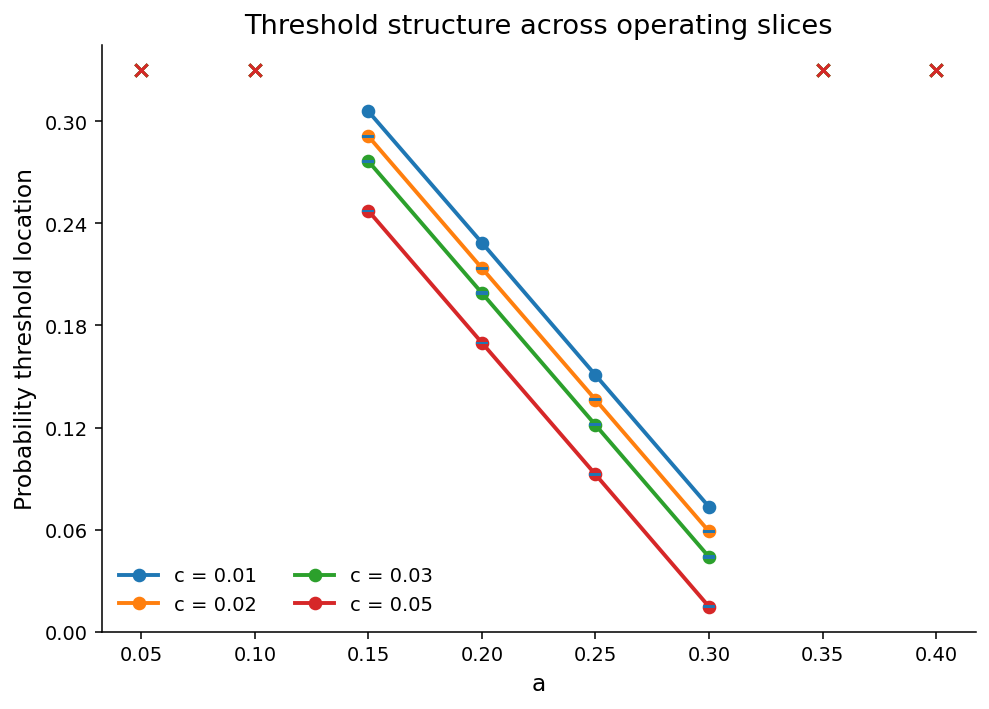

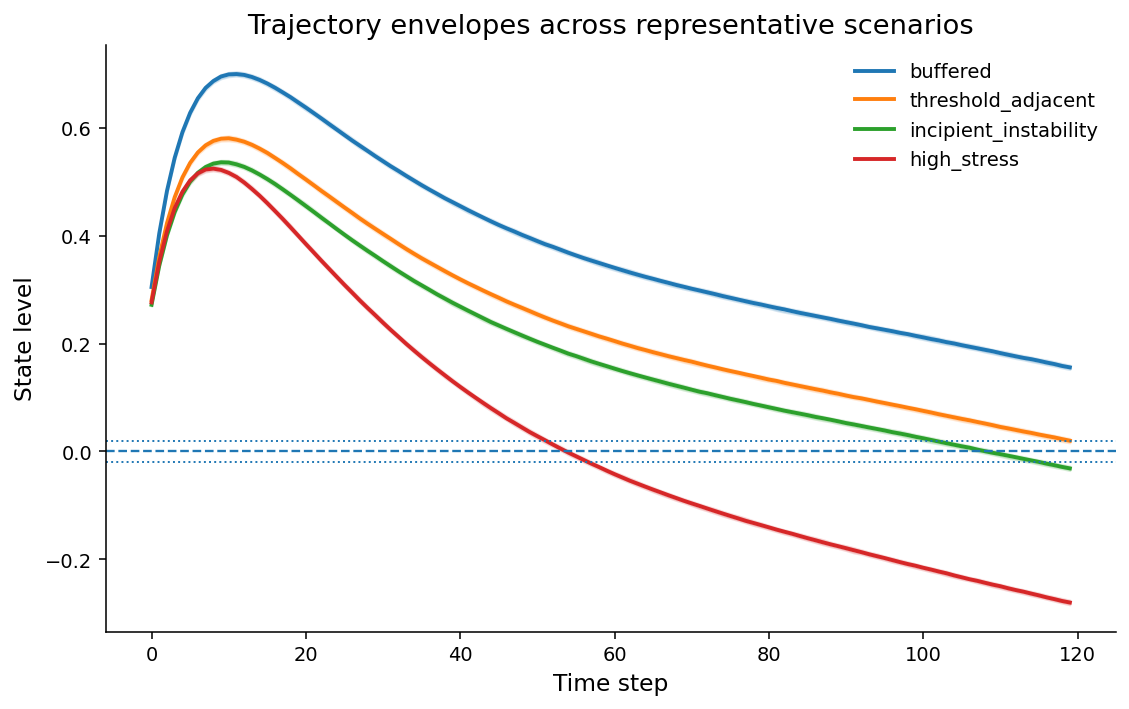

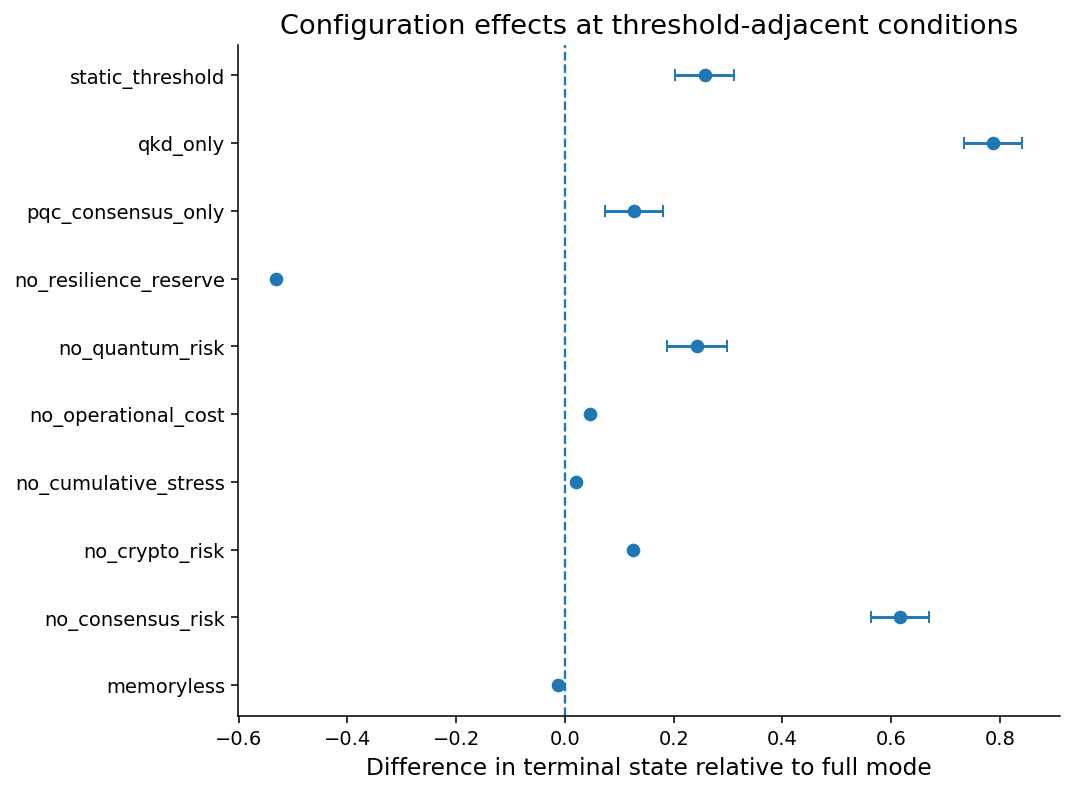

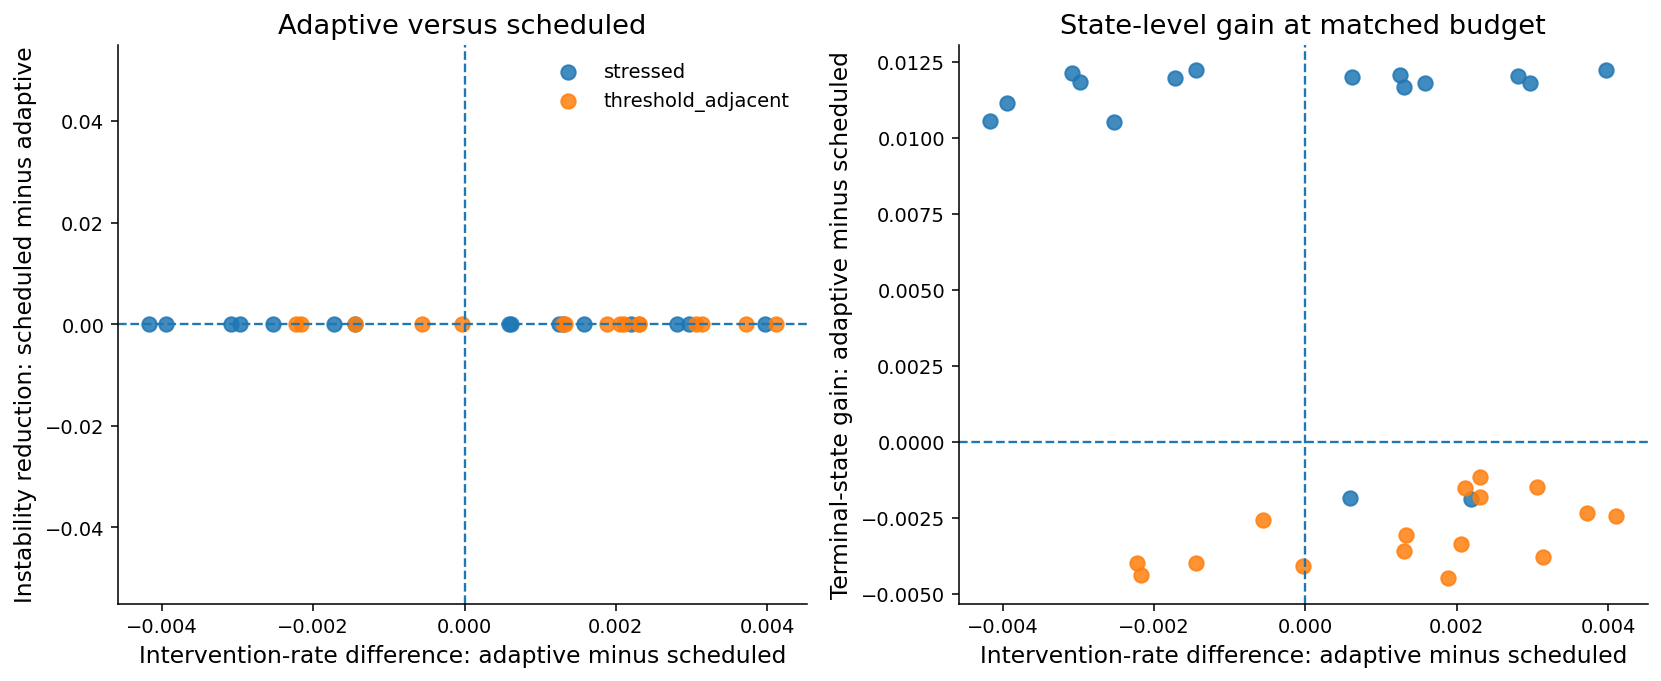

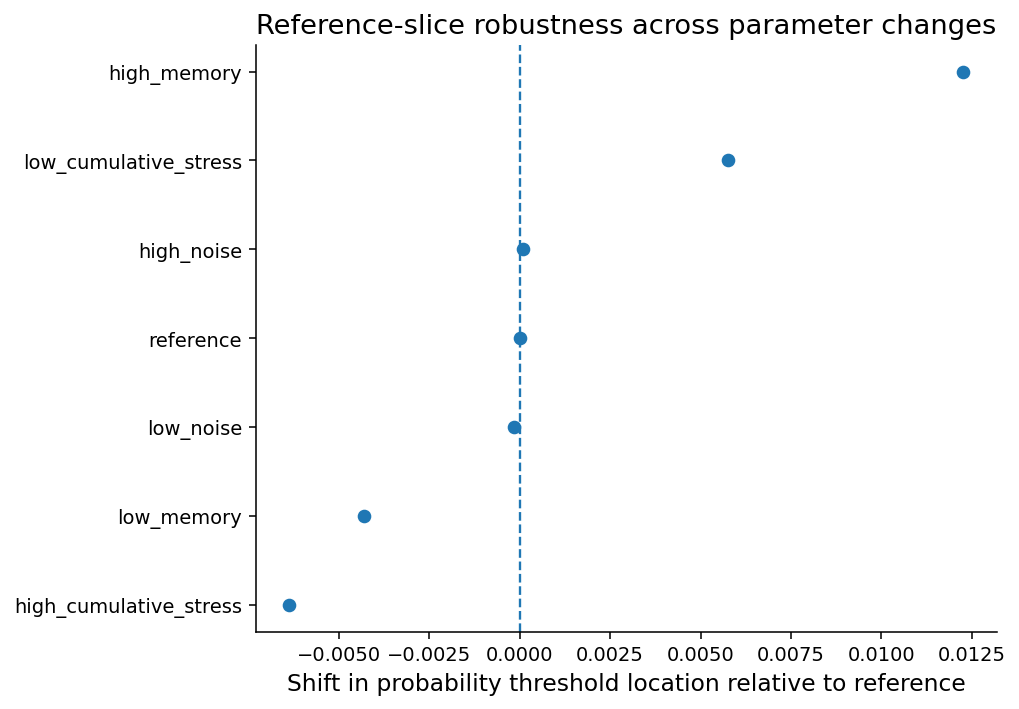

,figure,path
0,threshold_structure,F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
1,scenario_trajectories,F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
2,configuration_effects_threshold_adjacent,F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
3,policy_matched_budget,F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
4,parameter_robustness,F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...


In [14]:
from matplotlib.ticker import MaxNLocator

# Figure 1: threshold structure across operating slices
fig, ax = plt.subplots(figsize=(7.2, 5.2))

for c, g in boundary_df.groupby("c"):
    g = g.sort_values("a")
    ge = g[g["estimable_probability_boundary"]].copy()

    if not ge.empty:
        ax.plot(
            ge["a"],
            ge["eta_c_probability"],
            marker="o",
            linewidth=2,
            label=f"c = {c:.02f}",
        )

        yerr = np.vstack([
            ge["eta_c_probability"] - ge["eta_c_probability_low"],
            ge["eta_c_probability_high"] - ge["eta_c_probability"],
        ])

        ax.errorbar(
            ge["a"],
            ge["eta_c_probability"],
            yerr=yerr,
            fmt="none",
            capsize=3,
            linewidth=1,
        )

    gm = g[~g["estimable_probability_boundary"]].copy()
    if not gm.empty:
        ax.scatter(
            gm["a"],
            np.full(len(gm), ETA_GRID.max() + 0.01),
            marker="x",
            s=40,
        )

ax.set_xlabel("a")
ax.set_ylabel("Probability threshold location")
ax.set_title("Threshold structure across operating slices")
ax.set_ylim(ETA_GRID.min() - 0.005, ETA_GRID.max() + 0.025)
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

fig1_path = FIG_DIR / "fig_threshold_structure.png"
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 2: scenario trajectory envelopes
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for scenario_name, traces in scenario_trace_store.items():
    q10 = np.quantile(traces, 0.10, axis=0)
    q50 = np.quantile(traces, 0.50, axis=0)
    q90 = np.quantile(traces, 0.90, axis=0)

    line = ax.plot(q50, linewidth=2, label=scenario_name)[0]
    ax.fill_between(
        np.arange(T),
        q10,
        q90,
        alpha=0.18,
        color=line.get_color(),
    )

ax.axhline(0.0, linestyle="--", linewidth=1.2)
ax.axhline(M_PSI, linestyle=":", linewidth=1.0)
ax.axhline(-M_PSI, linestyle=":", linewidth=1.0)

ax.set_xlabel("Time step")
ax.set_ylabel("State level")
ax.set_title("Trajectory envelopes across representative scenarios")
ax.legend(frameon=False)
fig.tight_layout()

fig2_path = FIG_DIR / "fig_scenario_trajectories.png"
fig.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 3: configuration effects at threshold-adjacent conditions
plot_modes = panel_delta_summary[
    (panel_delta_summary["regime"] == "threshold_adjacent") &
    (panel_delta_summary["mode"] != "full")
].copy()

fig, ax = plt.subplots(figsize=(7.8, 5.8))

ax.errorbar(
    plot_modes["mean_delta_terminal_psi"],
    plot_modes["mode"],
    xerr=1.96 * plot_modes["se_delta_terminal_psi"],
    fmt="o",
    capsize=3,
)

ax.axvline(0.0, linestyle="--", linewidth=1.2)
ax.set_xlabel("Difference in terminal state relative to full mode")
ax.set_ylabel("")
ax.set_title("Configuration effects at threshold-adjacent conditions")
fig.tight_layout()

fig3_path = FIG_DIR / "fig_configuration_effects_threshold_adjacent.png"
fig.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 4: policy comparison at matched intervention budget
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))

for regime, g in policy_wide.groupby("regime"):
    axes[0].scatter(
        g["delta_intervention_adaptive_vs_scheduled"],
        g["delta_unstable_adaptive_vs_scheduled"],
        s=55,
        alpha=0.85,
        label=regime,
    )

axes[0].axhline(0.0, linestyle="--", linewidth=1.2)
axes[0].axvline(0.0, linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Intervention-rate difference: adaptive minus scheduled")
axes[0].set_ylabel("Instability reduction: scheduled minus adaptive")
axes[0].set_title("Adaptive versus scheduled")
axes[0].legend(frameon=False)

for regime, g in policy_wide.groupby("regime"):
    axes[1].scatter(
        g["delta_intervention_adaptive_vs_scheduled"],
        g["delta_terminal_adaptive_vs_scheduled"],
        s=55,
        alpha=0.85,
        label=regime,
    )

axes[1].axhline(0.0, linestyle="--", linewidth=1.2)
axes[1].axvline(0.0, linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Intervention-rate difference: adaptive minus scheduled")
axes[1].set_ylabel("Terminal-state gain: adaptive minus scheduled")
axes[1].set_title("State-level gain at matched budget")

fig.tight_layout()

fig4_path = FIG_DIR / "fig_policy_matched_budget.png"
fig.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 5: parameter robustness on the reference slice
plot_df = robustness_df.sort_values("delta_vs_reference").copy()

fig, ax = plt.subplots(figsize=(7.4, 5.2))

ax.errorbar(
    plot_df["delta_vs_reference"],
    plot_df["spec"],
    fmt="o",
    capsize=3,
)

ax.axvline(0.0, linestyle="--", linewidth=1.2)
ax.set_xlabel("Shift in probability threshold location relative to reference")
ax.set_ylabel("")
ax.set_title("Reference-slice robustness across parameter changes")
fig.tight_layout()

fig5_path = FIG_DIR / "fig_parameter_robustness.png"
fig.savefig(fig5_path, dpi=300, bbox_inches="tight")
plt.show()


figure_manifest = pd.DataFrame([
    {"figure": "threshold_structure", "path": str(fig1_path)},
    {"figure": "scenario_trajectories", "path": str(fig2_path)},
    {"figure": "configuration_effects_threshold_adjacent", "path": str(fig3_path)},
    {"figure": "policy_matched_budget", "path": str(fig4_path)},
    {"figure": "parameter_robustness", "path": str(fig5_path)},
])

figure_manifest_path = TABLE_DIR / "figure_manifest.csv"
figure_manifest.to_csv(figure_manifest_path, index=False)

figure_manifest

# Consolidated summary, artifact index, and run record

This cell collects the main outputs into a compact machine-readable summary and a readable text record. It stores the principal grid dimensions, threshold estimability counts, selected warning-rule parameters, configuration comparison summaries, policy comparison summaries, parameter-robustness results, and the locations of generated artifacts. The result is a single indexed record of the run that can be inspected without reconstructing the workflow from individual files.

In [15]:
run_summary = {
    "run_id": RUN_ID,
    "seed": SEED,
    "grid": {
        "eta_points": int(len(ETA_GRID)),
        "a_points": int(len(A_GRID)),
        "c_points": int(len(C_GRID)),
        "n_rep": int(N_REP),
        "n_boot": int(N_BOOT),
        "n_sc": int(N_SC),
    },
    "thresholds": {
        "estimable_mean_boundary_count": int(boundary_df["estimable_mean_boundary"].sum()),
        "estimable_probability_boundary_count": int(boundary_df["estimable_probability_boundary"].sum()),
        "non_estimable_probability_boundary_count": int((~boundary_df["estimable_probability_boundary"]).sum()),
    },
    "warning_rule": {
        "slope_window": int(best_rule["slope_window"]),
        "slope_threshold": float(best_rule["slope_threshold"]),
        "level_threshold": float(best_rule["level_threshold"]),
    },
    "key_results": {
        "reference_eta_c_probability": float(reference_eta_c),
        "policy_mean_delta_unstable_adaptive_vs_passive_stressed": float(
            policy_delta_summary.loc[
                policy_delta_summary["regime"] == "stressed",
                "mean_delta_unstable_adaptive_vs_passive"
            ].iloc[0]
        ),
        "policy_mean_delta_unstable_adaptive_vs_scheduled_stressed": float(
            policy_delta_summary.loc[
                policy_delta_summary["regime"] == "stressed",
                "mean_delta_unstable_adaptive_vs_scheduled"
            ].iloc[0]
        ),
        "policy_mean_delta_terminal_adaptive_vs_scheduled_stressed": float(
            policy_delta_summary.loc[
                policy_delta_summary["regime"] == "stressed",
                "mean_delta_terminal_adaptive_vs_scheduled"
            ].iloc[0]
        ),
    },
    "key_paths": {
        "manifest": str(manifest_path),
        "endpoint_table": str(endpoint_table_path),
        "endpoint_data": str(endpoint_data_path),
        "qc_table": str(qc_table_path),
        "threshold_table": str(boundary_table_path),
        "margin_table": str(margin_table_path),
        "configuration_panel": str(panel_table_path),
        "configuration_summary": str(panel_summary_path),
        "scenario_table": str(scenario_table_path),
        "scenario_data": str(scenario_data_path),
        "warning_grid": str(warning_grid_path),
        "warning_eval": str(warning_eval_path),
        "warning_rule_file": str(warning_rule_path),
        "policy_table": str(policy_table_path),
        "policy_schedule_table": str(schedule_table_path),
        "policy_delta_table": str(policy_delta_path),
        "policy_summary": str(policy_summary_path),
        "robustness_table": str(robustness_table_path),
        "figure_manifest": str(figure_manifest_path),
    },
}

summary_json_path = META_DIR / f"run_summary_{RUN_ID}.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

summary_txt_path = LOG_DIR / f"run_summary_{RUN_ID}.txt"
with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write("Run summary\n")
    f.write("=" * 80 + "\n\n")

    f.write("Environment\n")
    f.write("-" * 80 + "\n")
    f.write(f"run_id: {RUN_ID}\n")
    f.write(f"seed: {SEED}\n")
    f.write(f"execution_mode: {'colab' if IN_COLAB else 'local'}\n")
    f.write(f"root_dir: {ROOT_DIR}\n")
    f.write(f"output_dir: {OUTPUT_DIR}\n\n")

    f.write("Grid\n")
    f.write("-" * 80 + "\n")
    f.write(f"eta_points: {len(ETA_GRID)}\n")
    f.write(f"a_points: {len(A_GRID)}\n")
    f.write(f"c_points: {len(C_GRID)}\n")
    f.write(f"n_rep: {N_REP}\n")
    f.write(f"n_boot: {N_BOOT}\n")
    f.write(f"n_sc: {N_SC}\n\n")

    f.write("Threshold summary\n")
    f.write("-" * 80 + "\n")
    f.write(f"estimable_mean_boundary_count: {int(boundary_df['estimable_mean_boundary'].sum())}\n")
    f.write(f"estimable_probability_boundary_count: {int(boundary_df['estimable_probability_boundary'].sum())}\n")
    f.write(f"non_estimable_probability_boundary_count: {int((~boundary_df['estimable_probability_boundary']).sum())}\n\n")

    f.write("Selected warning rule\n")
    f.write("-" * 80 + "\n")
    f.write(f"slope_window: {int(best_rule['slope_window'])}\n")
    f.write(f"slope_threshold: {float(best_rule['slope_threshold'])}\n")
    f.write(f"level_threshold: {float(best_rule['level_threshold'])}\n\n")

    f.write("Scenario summary\n")
    f.write("-" * 80 + "\n")
    f.write(scenario_df.to_string(index=False))
    f.write("\n\n")

    f.write("Warning evaluation\n")
    f.write("-" * 80 + "\n")
    f.write(early_warning_df.to_string(index=False))
    f.write("\n\n")

    f.write("Configuration comparison summary\n")
    f.write("-" * 80 + "\n")
    f.write(panel_delta_summary.to_string(index=False))
    f.write("\n\n")

    f.write("Policy comparison summary\n")
    f.write("-" * 80 + "\n")
    f.write(policy_delta_summary.to_string(index=False))
    f.write("\n\n")

    f.write("Parameter robustness\n")
    f.write("-" * 80 + "\n")
    f.write(robustness_df.to_string(index=False))
    f.write("\n\n")

    f.write("Figure index\n")
    f.write("-" * 80 + "\n")
    f.write(figure_manifest.to_string(index=False))
    f.write("\n\n")

    f.write("Artifact index\n")
    f.write("-" * 80 + "\n")
    for key, value in run_summary["key_paths"].items():
        f.write(f"{key}: {value}\n")

artifact_index = pd.DataFrame(
    [{"name": key, "path": value} for key, value in run_summary["key_paths"].items()]
).sort_values("name").reset_index(drop=True)

artifact_index_path = TABLE_DIR / "artifact_index.csv"
artifact_index.to_csv(artifact_index_path, index=False)

final_check = {
    "summary_json_path": str(summary_json_path),
    "summary_txt_path": str(summary_txt_path),
    "artifact_index_path": str(artifact_index_path),
    "figure_count": int(len(figure_manifest)),
    "artifact_index_rows": int(len(artifact_index)),
}

artifact_index, final_check

(                     name                                               path
 0     configuration_panel  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 1   configuration_summary  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 2           endpoint_data  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 3          endpoint_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 4         figure_manifest  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 5                manifest  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 6            margin_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 7      policy_delta_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 8   policy_schedule_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 9          policy_summary  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 10           policy_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\GitHub\Q-TRU...
 11               qc_table  F:\MBZUAI UAE\16-IEEE-QTRUSTChain\Gi